<a href="https://colab.research.google.com/github/rajeev-bhardwajsharma/BarcaIntel-ligenica/blob/main/player_role_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#  Loading Data
df_luis = pd.read_csv('/content/sample_data/barca_filtered_events_luis.csv')
df_valverde = pd.read_csv('/content/sample_data/barca_filtered_events_after.csv')


In [15]:
#to make reading name more user friendly
player_name_map = {
    # This is your provided map
    'Lionel Andrés Messi Cuccittini': 'Messi', 'Luis Alberto Suárez Díaz': 'Suárez',
    'Neymar da Silva Santos Junior': 'Neymar', 'Sergio Busquets i Burgos': 'Busquets',
    'Ivan Rakitić': 'Rakitić', 'Sergi Roberto Carnicer': 'Sergi Roberto',
    'Marc-André ter Stegen': 'Ter Stegen', 'Gerard Piqué Bernabéu': 'Piqué',
    'Jordi Alba Ramos': 'Alba', 'Antoine Griezmann': 'Griezmann',
    'Arturo Erasmo Pardo Vidal': 'Vidal', 'Clément Nicolas Laurent Lenglet': 'Lenglet',
    'Nélson Cabral Semedo': 'Semedo', 'Samuel Yves Umtiti': 'Umtiti',
    'Andrés Iniesta Luján': 'Iniesta', 'Denis Suárez Fernández': 'Denis Suárez',
    'Javier Alejandro Mascherano': 'Mascherano', 'Daniel Alves da Silva': 'Dani Alves',
    'Xavier Hernández Creus': 'Xavi', 'Pedro Eliezer Rodríguez Ledesma': 'Pedro',
    'Claudio Andrés Bravo Muñoz': 'Bravo', 'Arda Turan': 'Arda Turan',
    'Adriano Correia Claro': 'Adriano', 'Philippe Coutinho Correia': 'Coutinho',
    'Ousmane Dembélé': 'Dembélé', 'Arthur Henrique Ramos de Oliveira Melo': 'Arthur',
    'Frenkie de Jong': 'De Jong', 'Anssumane Fati': 'Ansu Fati'
}

In [16]:
# Applying  the map to create a new 'player_name' column
df_luis['player_name'] = df_luis['player'].map(player_name_map)
df_valverde['player_name'] = df_valverde['player'].map(player_name_map)
df_luis = df_luis.dropna(subset=['player_name']).drop(columns=['player'])
df_valverde = df_valverde.dropna(subset=['player_name']).drop(columns=['player'])


In [17]:
#  Calculateing Minutes and Define Cohorts(similar family) (Now using 'player_name')
def calculate_minutes_played(df):
    minutes_per_match = df.groupby(['match_id', 'player_name'])['minute'].max().reset_index()
    total_minutes = minutes_per_match.groupby('player_name')['minute'].sum().reset_index()
    return total_minutes.rename(columns={'minute': 'total_minutes_played'})

In [18]:
luis_player_minutes = calculate_minutes_played(df_luis)
valverde_player_minutes = calculate_minutes_played(df_valverde)

MINUTES_THRESHOLD = 1500
luis_cohort_list = luis_player_minutes[luis_player_minutes['total_minutes_played'] > MINUTES_THRESHOLD]['player_name'].tolist()
valverde_cohort_list = valverde_player_minutes[valverde_player_minutes['total_minutes_played'] > MINUTES_THRESHOLD]['player_name'].tolist()
overlap_cohort_list = list(set(luis_cohort_list) & set(valverde_cohort_list))

print(f"--- Player Analysis Groups (Threshold: {MINUTES_THRESHOLD} mins) ---")
print(f"Luis Enrique Cohort ({len(luis_cohort_list)}): {luis_cohort_list}")
print(f"Valverde Cohort ({len(valverde_cohort_list)}): {valverde_cohort_list}")
print(f"Overlap Cohort ({len(overlap_cohort_list)}): {overlap_cohort_list}")

--- Player Analysis Groups (Threshold: 1500 mins) ---
Luis Enrique Cohort (19): ['Adriano', 'Alba', 'Arda Turan', 'Bravo', 'Busquets', 'Dani Alves', 'Denis Suárez', 'Iniesta', 'Mascherano', 'Messi', 'Neymar', 'Pedro', 'Piqué', 'Rakitić', 'Sergi Roberto', 'Suárez', 'Ter Stegen', 'Umtiti', 'Xavi']
Valverde Cohort (18): ['Alba', 'Ansu Fati', 'Arthur', 'Busquets', 'Coutinho', 'De Jong', 'Dembélé', 'Denis Suárez', 'Griezmann', 'Iniesta', 'Messi', 'Piqué', 'Rakitić', 'Semedo', 'Sergi Roberto', 'Suárez', 'Ter Stegen', 'Umtiti']
Overlap Cohort (11): ['Suárez', 'Alba', 'Umtiti', 'Piqué', 'Messi', 'Ter Stegen', 'Busquets', 'Iniesta', 'Sergi Roberto', 'Denis Suárez', 'Rakitić']


In [19]:
#  Advanced Feature Engineering
def get_advanced_player_stats(df, minutes_df):
    player_agg = df.groupby('player_name').agg(
        passes=('event_type', lambda x: (x == 'Pass').sum()), shots=('event_type', lambda x: (x == 'Shot').sum()),
        dribbles=('event_type', lambda x: (x == 'Dribble').sum()), interceptions=('event_type', lambda x: (x == 'Interception').sum()),
        duels=('event_type', lambda x: (x == 'Duel').sum()), shot_assists=('shot_assist', 'count'), goal_assists=('goal_assist', 'count')
    ).reset_index()
    df['progressive_pass_dist'] = (df['pass_end_x'] - df['location_x']).clip(lower=0)
    df['progressive_carry_dist'] = (df['carry_end_location_x'] - df['location_x']).clip(lower=0)
    progression_stats = df.groupby('player_name').agg(
        total_prog_pass_dist=('progressive_pass_dist', 'sum'), total_prog_carry_dist=('progressive_carry_dist', 'sum')
    ).reset_index()
    shot_quality = df.dropna(subset=['shot_statsbomb_xg']).groupby('player_name')['shot_statsbomb_xg'].mean().reset_index()
    shot_quality = shot_quality.rename(columns={'shot_statsbomb_xg': 'avg_shot_xg'})
    player_stats = player_agg.merge(progression_stats, on='player_name', how='left')
    player_stats = player_stats.merge(shot_quality, on='player_name', how='left')
    player_stats = player_stats.merge(minutes_df, on='player_name', how='left')
    player_stats = player_stats.fillna(0)
    stats_cols = ['passes', 'shots', 'dribbles', 'interceptions', 'duels', 'shot_assists', 'goal_assists', 'total_prog_pass_dist', 'total_prog_carry_dist']
    for col in stats_cols:
        player_stats[col + '_p90'] = player_stats[col] / ((player_stats['total_minutes_played'] / 90) + 1e-6)
    return player_stats

In [20]:

luis_advanced_stats = get_advanced_player_stats(df_luis, luis_player_minutes)
valverde_advanced_stats = get_advanced_player_stats(df_valverde, valverde_player_minutes)


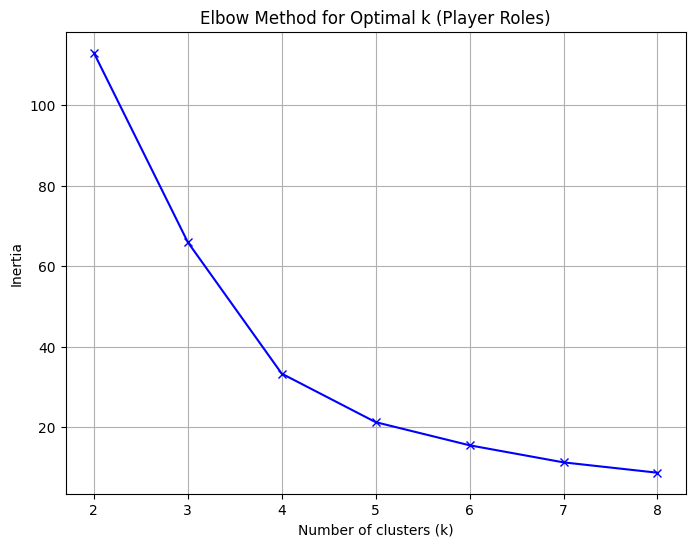

In [21]:
#elbow method to determine k

inertia = []
K = range(2, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features_adv)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (Player Roles)')
plt.grid(True)
plt.show()

In [22]:

#    doing Filtering, Clustering, and Output
luis_cohort_stats = luis_advanced_stats[luis_advanced_stats['player_name'].isin(luis_cohort_list)].copy()
valverde_cohort_stats = valverde_advanced_stats[valverde_advanced_stats['player_name'].isin(valverde_cohort_list)].copy()
luis_cohort_stats['manager'] = 'Luis Enrique'
valverde_cohort_stats['manager'] = 'Ernesto Valverde'
df_cohort_players = pd.concat([luis_cohort_stats, valverde_cohort_stats], ignore_index=True)

features_for_clustering = [
    'passes_p90', 'shots_p90', 'dribbles_p90', 'interceptions_p90', 'duels_p90',
    'shot_assists_p90', 'goal_assists_p90', 'total_prog_pass_dist_p90',
    'total_prog_carry_dist_p90', 'avg_shot_xg'
]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cohort_players[features_for_clustering])

optimal_k = 4 #from the elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cohort_players['role_cluster'] = kmeans.fit_predict(scaled_features)

role_centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_for_clustering)
print("\n--- The DNA of Each Player Role (Cluster Centroids) ---")
print(role_centroids)

print("\n" + "="*50)
print("\n--- The Players in Each Role ---")
for i in range(optimal_k):
    print(f"\n--- ROLE CLUSTER {i} ---")
    cluster_df = df_cohort_players[df_cohort_players['role_cluster'] == i]
    cluster_df.loc[:, 'is_overlap'] = cluster_df['player_name'].isin(overlap_cohort_list)
    print(cluster_df[['player_name', 'manager', 'is_overlap']].sort_values(
        by=['is_overlap', 'player_name'], ascending=[False, True]
    ))


--- The DNA of Each Player Role (Cluster Centroids) ---
   passes_p90  shots_p90  dribbles_p90  interceptions_p90  duels_p90  \
0   63.733056   0.479989      1.139359           0.531521   1.376673   
1   30.753512   1.596975      2.373233           0.120644   0.699531   
2   32.833828   0.000000      0.037129           0.000000   0.003373   
3   56.829103   4.434215      7.721931           0.099821   0.443257   

   shot_assists_p90  goal_assists_p90  total_prog_pass_dist_p90  \
0         63.733056         63.733056                433.754455   
1         30.753512         30.753512                124.608150   
2         32.833828         32.833828                717.130022   
3         56.829103         56.829103                372.712282   

   total_prog_carry_dist_p90   avg_shot_xg  
0                 155.988528  9.933607e-02  
1                 102.711997  1.390303e-01  
2                  38.703345  1.387779e-17  
3                 232.892602  1.376716e-01  


--- The Players in 

/tmp/ipython-input-3067670101.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df.loc[:, 'is_overlap'] = cluster_df['player_name'].isin(overlap_cohort_list)
/tmp/ipython-input-3067670101.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df.loc[:, 'is_overlap'] = cluster_df['player_name'].isin(overlap_cohort_list)
/tmp/ipython-input-3067670101.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [ ]:
!pip install mplsoccer


  Preparing Data for Visualization
--- Step 5: Generating Final Visualization ---


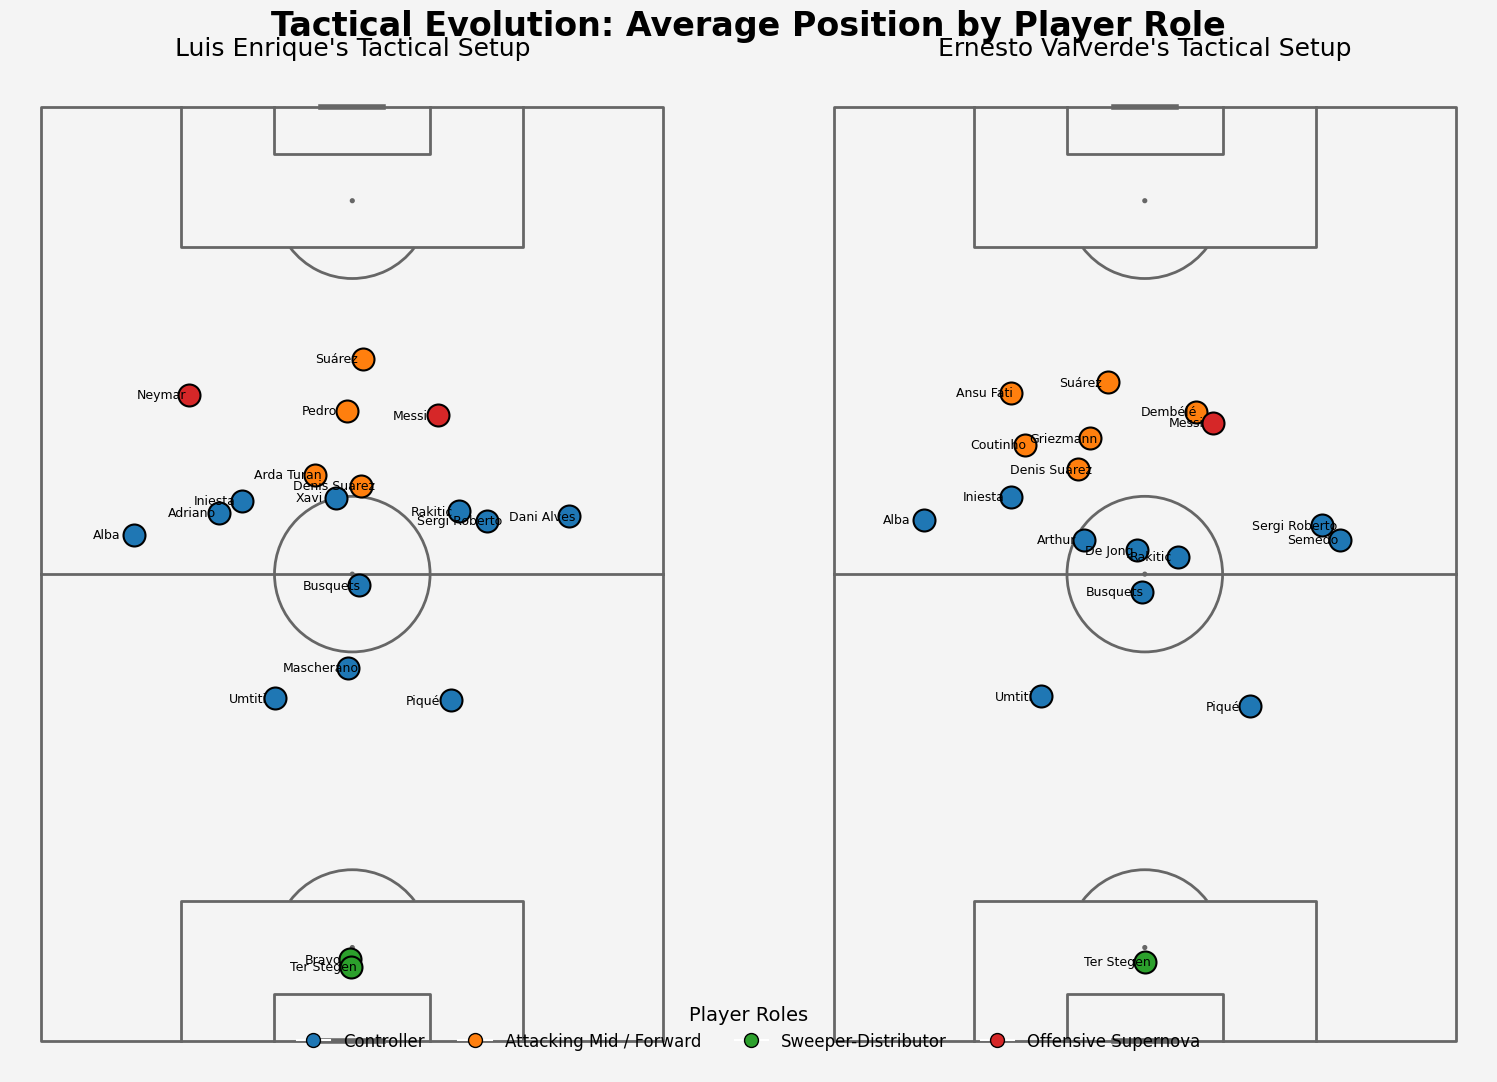

In [24]:
print("  Preparing Data for Visualization")
df_luis_roles_full = df_luis.merge(df_cohort_players[df_cohort_players['manager'] == 'Luis Enrique'][['player_name', 'role_cluster']], on='player_name', how='inner')
df_valverde_roles_full = df_valverde.merge(df_cohort_players[df_cohort_players['manager'] == 'Ernesto Valverde'][['player_name', 'role_cluster']], on='player_name', how='inner')

luis_player_avg_pos = df_luis_roles_full.groupby(['player_name', 'role_cluster'])[['location_x', 'location_y']].mean().reset_index()
valverde_player_avg_pos = df_valverde_roles_full.groupby(['player_name', 'role_cluster'])[['location_x', 'location_y']].mean().reset_index()

role_names = {0: 'Controller', 1: 'Attacking Mid / Forward', 2: 'Sweeper-Distributor', 3: 'Offensive Supernova'}
luis_player_avg_pos['role_name'] = luis_player_avg_pos['role_cluster'].map(role_names)
valverde_player_avg_pos['role_name'] = valverde_player_avg_pos['role_cluster'].map(role_names)

role_colors = sns.color_palette("tab10", n_colors=4)
color_map = {role_names[i]: role_colors[i] for i in sorted(role_names.keys())}

# --- Step 5: Generate the Final Tactical Map ---
print("--- Step 5: Generating Final Visualization ---")
pitch = VerticalPitch(pitch_type='statsbomb', line_color='#666666', pitch_color='#f4f4f4')
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 11))
fig.set_facecolor('#f4f4f4')

# Plot Luis Enrique
axes[0].set_title("Luis Enrique's Tactical Setup", fontsize=18, pad=15)
for i, row in luis_player_avg_pos.iterrows():
    color = color_map.get(row['role_name'], 'grey')
    pitch.scatter(row.location_x, row.location_y, s=250, c=[color], ax=axes[0], ec='black', lw=1.5, zorder=2)
    pitch.annotate(row['player_name'], xy=(row.location_x, row.location_y - 3.5), ax=axes[0], va='center', ha='center', color='black', fontsize=9, zorder=3)

# Plot Ernesto Valverde
axes[1].set_title("Ernesto Valverde's Tactical Setup", fontsize=18, pad=15)
for i, row in valverde_player_avg_pos.iterrows():
    color = color_map.get(row['role_name'], 'grey')
    pitch.scatter(row.location_x, row.location_y, s=250, c=[color], ax=axes[1], ec='black', lw=1.5, zorder=2)
    pitch.annotate(row['player_name'], xy=(row.location_x, row.location_y - 3.5), ax=axes[1], va='center', ha='center', color='black', fontsize=9, zorder=3)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=10, markeredgecolor='black') for label, color in color_map.items()]
fig.legend(handles=handles, title="Player Roles", loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), fontsize=12, title_fontsize=14, frameon=False)

fig.suptitle("Tactical Evolution: Average Position by Player Role", fontsize=24, y=0.98, fontweight='bold')
plt.show()

In [25]:
from sklearn.mixture import GaussianMixture
import pandas as pd

# We will use the final dataframes from the last step:
# df_cohort_players (contains player info and role_cluster from K-Means)
# scaled_features (the scaled stats for our cohort)

#  Fiting the GMM
# We use n_components=4 to find the same number of roles as K-Means for comparison
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
gmm.fit(scaled_features)

# Predict the probability of each player belonging to each cluster
probabilities = gmm.predict_proba(scaled_features)


# Createing a dataframe with the probabilities
prob_df = pd.DataFrame(probabilities, columns=[f'Prob_Role_{i}' for i in range(4)])

# Combine with our player info dataframe
gmm_results = pd.concat([df_cohort_players.reset_index(drop=True), prob_df], axis=1)

# Display the results, rounded for clarity
print(" GMM Role Probabilities for Each Playe")
display_cols = ['player_name', 'manager', 'Prob_Role_0', 'Prob_Role_1', 'Prob_Role_2', 'Prob_Role_3']
print(gmm_results[display_cols].round(2).sort_values(by='player_name'))


#  Identifying the Most Hybrid Player
#  finding players who don't fit purely into one role (e.g., no single probability is > 90%)
hybrid_players = gmm_results[probabilities.max(axis=1) < 0.90]

print("\n" + "="*50)
print("\n--- Potentially Hybrid Players (No single role > 90% probability) ---")
if not hybrid_players.empty:
    print(hybrid_players[display_cols].round(2).sort_values(by='player_name'))
else:
    print("No distinctly hybrid player found with this model.")

--- GMM Role Probabilities for Each Player ---
      player_name           manager  Prob_Role_0  Prob_Role_1  Prob_Role_2  \
0         Adriano      Luis Enrique          1.0          0.0          0.0   
1            Alba      Luis Enrique          1.0          0.0          0.0   
19           Alba  Ernesto Valverde          1.0          0.0          0.0   
20      Ansu Fati  Ernesto Valverde          0.0          1.0          0.0   
2      Arda Turan      Luis Enrique          0.0          1.0          0.0   
21         Arthur  Ernesto Valverde          1.0          0.0          0.0   
3           Bravo      Luis Enrique          0.0          0.0          1.0   
4        Busquets      Luis Enrique          1.0          0.0          0.0   
22       Busquets  Ernesto Valverde          1.0          0.0          0.0   
23       Coutinho  Ernesto Valverde          0.0          1.0          0.0   
5      Dani Alves      Luis Enrique          1.0          0.0          0.0   
24        De Jong

In [26]:
from sklearn.ensemble import IsolationForest
import numpy as np

# We use the same scaled_features from our previous steps

#  Fiting the Isolation Forest Model
# The contaminatio parameter tells the model what percentage of data might be outliers.
# auto is a good starting point.
iso_forest = IsolationForest(contamination='auto', random_state=42)
outlier_prediction = iso_forest.fit_predict(scaled_features)

# The model predicts -1 for outliers and 1 for inliers (normal players)
df_cohort_players['is_outlier'] = outlier_prediction

# --- Step 2: Show the Results ---
outliers = df_cohort_players[df_cohort_players['is_outlier'] == -1]

print("--- Anomaly Detection Results (Isolation Forest) ---")
if not outliers.empty:
    print("The following players were flagged as statistical outliers:")
    print(outliers[['player_name', 'manager', 'role_cluster']])
else:
    print("No significant statistical outliers were found in the cohort.")

--- Anomaly Detection Results (Isolation Forest) ---
The following players were flagged as statistical outliers:
     player_name           manager  role_cluster
2     Arda Turan      Luis Enrique             1
3          Bravo      Luis Enrique             2
5     Dani Alves      Luis Enrique             0
8     Mascherano      Luis Enrique             0
9          Messi      Luis Enrique             3
10        Neymar      Luis Enrique             3
15        Suárez      Luis Enrique             1
16    Ter Stegen      Luis Enrique             2
20     Ansu Fati  Ernesto Valverde             1
22      Busquets  Ernesto Valverde             0
25       Dembélé  Ernesto Valverde             1
26  Denis Suárez  Ernesto Valverde             1
29         Messi  Ernesto Valverde             3
34        Suárez  Ernesto Valverde             1
35    Ter Stegen  Ernesto Valverde             2


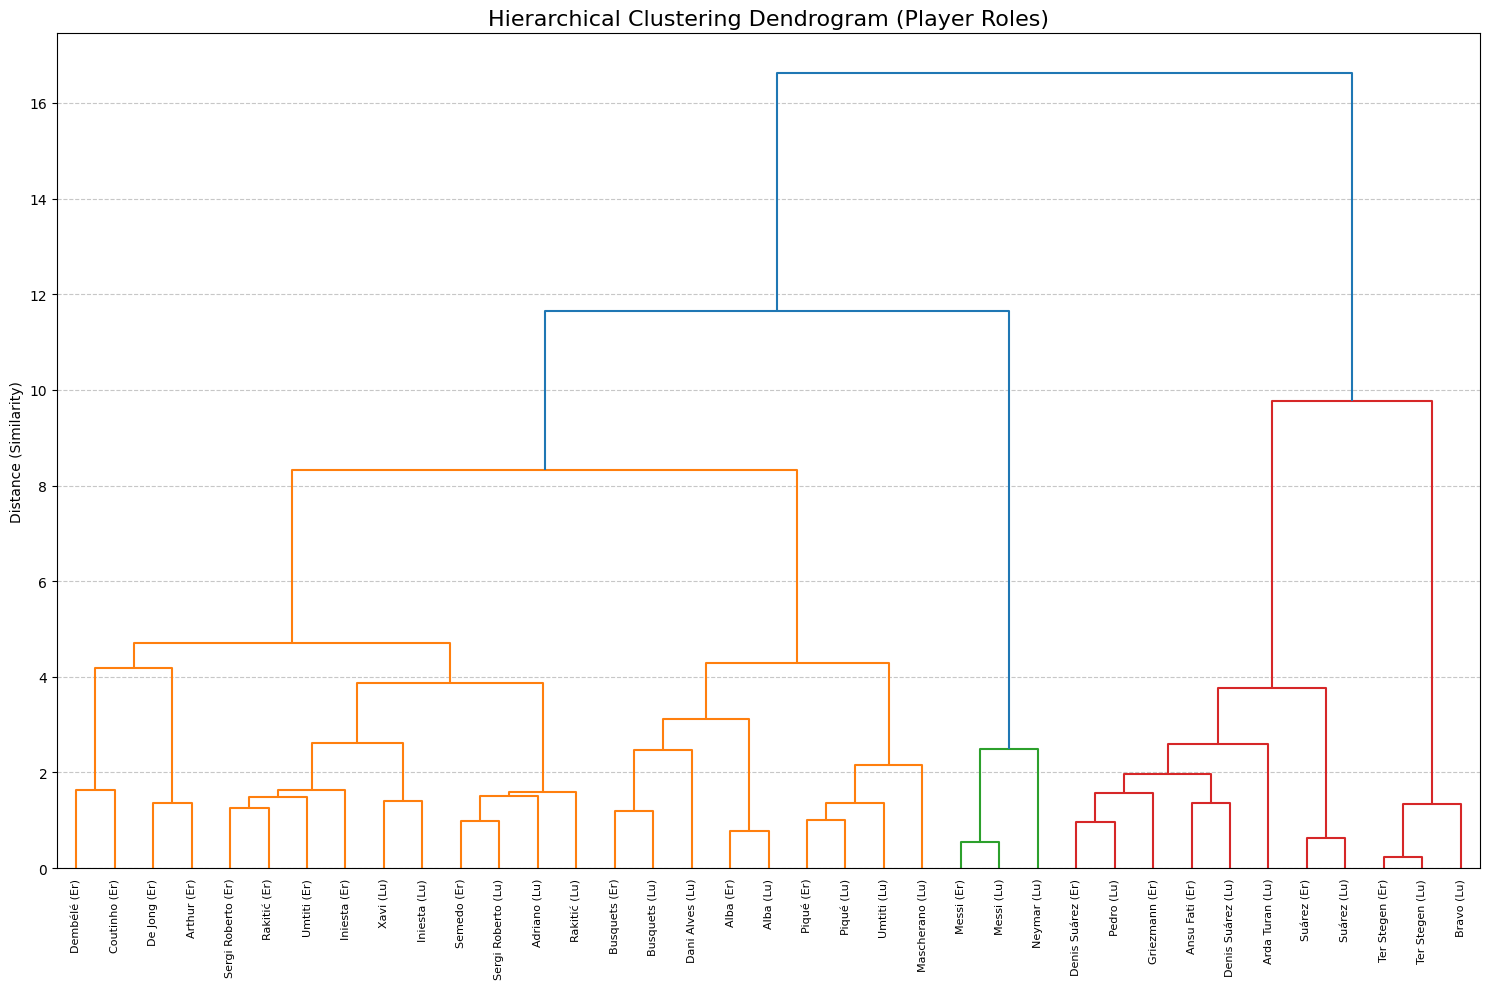

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# We use the same scaled_features and the df_cohort_players from our analysis

#  Performing Hierarchical Clusterin
linked = linkage(scaled_features, method='ward')

# Create the Dendrogram Plot
plt.figure(figsize=(15, 10))

#  the player names and managers for the labels
labels = [f"{row['player_name']} ({row['manager'][:2]})" for index, row in df_cohort_players.iterrows()]

dendrogram(linked,
           orientation='top',
           labels=labels,
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Player Roles)', fontsize=16)
plt.ylabel('Distance (Similarity)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()